In [1]:
import pandas as pd

# 1. Load the Data
# Ensure 'train.csv' is in the same folder as this notebook/script
try:
    df = pd.read_csv('train.csv')
    print("✅ File loaded successfully.\n")
except FileNotFoundError:
    print("❌ Error: 'train.csv' not found. Please upload the file.")

# 2. Check Volume (How much data?)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 3. Check Data Types (Are numbers reading as numbers?)
print("\n--- Data Types ---")
print(df.dtypes)

# 4. Check for Missing Values (Nulls)
print("\n--- Missing Values ---")
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("✅ No missing values found.")
else:
    print("⚠️ Missing values detected:")
    print(null_counts[null_counts > 0])

✅ File loaded successfully.

Dataset Shape: 1913 rows, 14 columns

--- Data Types ---
participant_id                 int64
age_group                      int64
identity_code                  int64
cultural_background            int64
upbringing_influence           int64
focus_intensity              float64
consistency_score              int64
external_guidance_usage        int64
support_environment_score      int64
hobby_engagement_level         int64
physical_activity_index        int64
creative_expression_index      int64
altruism_score                 int64
personality_cluster           object
dtype: object

--- Missing Values ---
✅ No missing values found.


In [2]:
import pandas as pd

# 1. Load Data
df = pd.read_csv('train.csv')

print("--- STEP 2: FACTOR ANALYSIS & TARGET CHECK ---")

# 1. The "Unique Value" Test
# This helps us separate "scores" from "categories"
print("\n[Unique Values per Column]")
print("Columns with < 20 unique values are likely Categories:")
for col in df.columns:
    # We skip the ID column as it's always unique
    if col == 'participant_id':
        continue
        
    n_unique = df[col].nunique()
    dtype = df[col].dtype
    
    # Labeling based on count
    label = "Continuous (Score)" if n_unique > 20 else "Categorical (Factor)"
    print(f"{col:<25} : {n_unique:>4} unique values -> {label}")

# 2. The Target Imbalance Check
# This is CRITICAL for the "Macro F1" requirement
print("\n\n[Target Variable Distribution]")
counts = df['personality_cluster'].value_counts()
percent = df['personality_cluster'].value_counts(normalize=True) * 100

results = pd.DataFrame({'Count': counts, 'Percentage': percent})
print(results)

# 3. Check the dominant class ratio
dominant_class_ratio = percent.iloc[0]
print(f"\n⚠️ Warning: If a model guesses '{results.index[0]}' for everyone, it gets {dominant_class_ratio:.2f}% Accuracy.")

--- STEP 2: FACTOR ANALYSIS & TARGET CHECK ---

[Unique Values per Column]
Columns with < 20 unique values are likely Categories:
age_group                 :    4 unique values -> Categorical (Factor)
identity_code             :    2 unique values -> Categorical (Factor)
cultural_background       :    4 unique values -> Categorical (Factor)
upbringing_influence      :    5 unique values -> Categorical (Factor)
focus_intensity           : 1913 unique values -> Continuous (Score)
consistency_score         :   30 unique values -> Continuous (Score)
external_guidance_usage   :    2 unique values -> Categorical (Factor)
support_environment_score :    5 unique values -> Categorical (Factor)
hobby_engagement_level    :    2 unique values -> Categorical (Factor)
physical_activity_index   :    2 unique values -> Categorical (Factor)
creative_expression_index :    2 unique values -> Categorical (Factor)
altruism_score            :    2 unique values -> Categorical (Factor)
personality_cluster   

--- STEP 3: FEATURE SEPARATION CHECK ---


C:\Users\Aksha\AppData\Local\Temp\ipykernel_20392\473910069.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='personality_cluster', y='focus_intensity', palette='viridis')
C:\Users\Aksha\AppData\Local\Temp\ipykernel_20392\473910069.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='personality_cluster', y='consistency_score', palette='viridis')


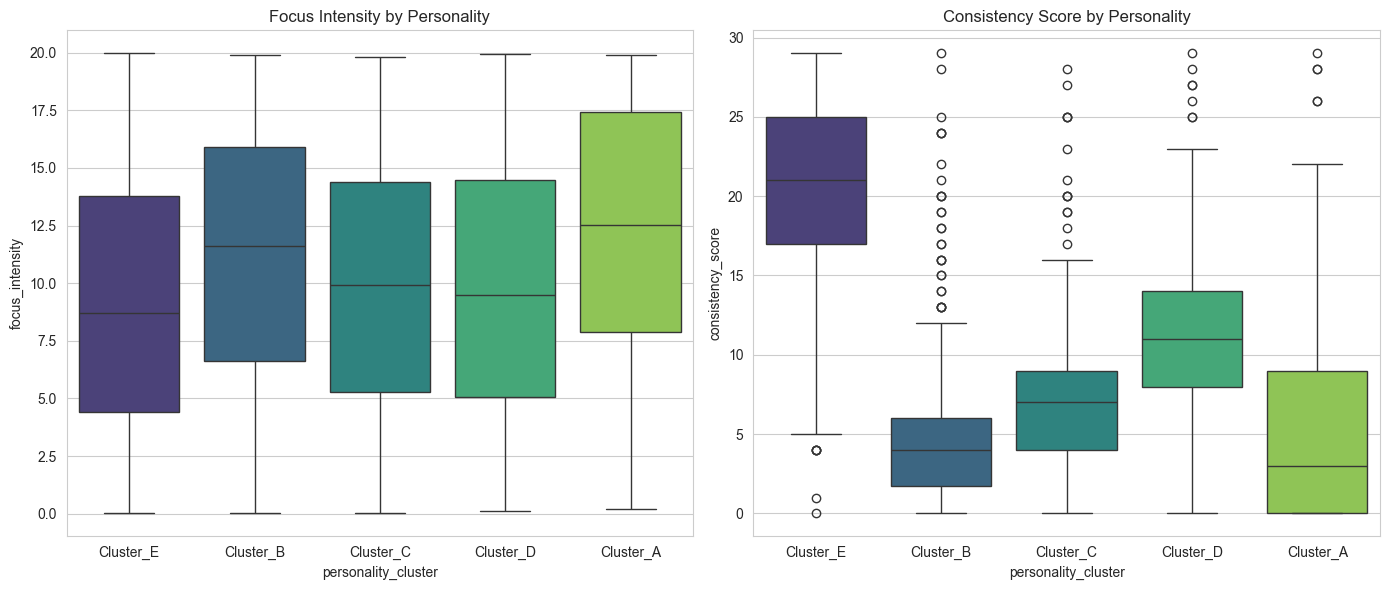


[Creative Expression vs Personality]
creative_expression_index          0          1
personality_cluster                            
Cluster_A                  80.000000  20.000000
Cluster_B                  72.272727  27.727273
Cluster_C                  81.372549  18.627451
Cluster_D                  78.963415  21.036585
Cluster_E                  82.032854  17.967146

Interpretation Guide:
- If the Boxplots overlap completely: These features are weak predictors.
- If the Crosstab shows 0% or 100% for a cluster: That feature is a 'Golden Rule' predictor.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('train.csv')

print("--- STEP 3: FEATURE SEPARATION CHECK ---")

# Setup the plot style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# 1. FOCUS INTENSITY vs CLUSTER
# Does one personality type focus better than others?
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='personality_cluster', y='focus_intensity', palette='viridis')
plt.title("Focus Intensity by Personality")

# 2. CONSISTENCY SCORE vs CLUSTER
# Is one personality type more consistent?
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='personality_cluster', y='consistency_score', palette='viridis')
plt.title("Consistency Score by Personality")

plt.tight_layout()
plt.show()

# 3. The "Creative" Check
# Let's see if 'Creative Expression' maps to a specific cluster
print("\n[Creative Expression vs Personality]")
# We use a Crosstab to see the % of 'Creatives' in each cluster
creative_cross = pd.crosstab(df['personality_cluster'], df['creative_expression_index'], normalize='index') * 100
print(creative_cross)

print("\nInterpretation Guide:")
print("- If the Boxplots overlap completely: These features are weak predictors.")
print("- If the Crosstab shows 0% or 100% for a cluster: That feature is a 'Golden Rule' predictor.")

--- DEEP DIVE ANALYSIS ---


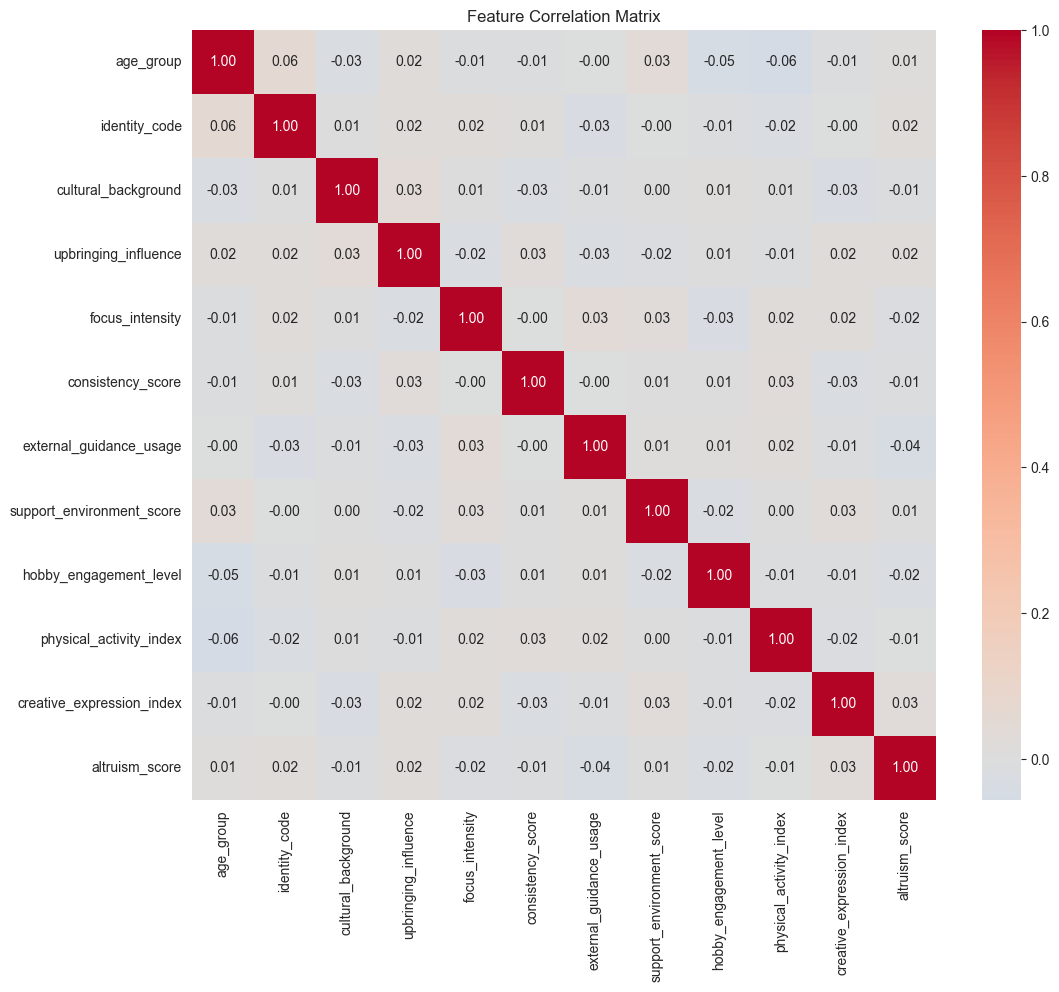


[Cluster Fingerprints - Average Values]
                     age_group  identity_code  cultural_background  \
personality_cluster                                                  
Cluster_A            16.317647       0.388235             1.011765   
Cluster_B            16.527273       0.527273             0.909091   
Cluster_C            16.503268       0.513072             0.866013   
Cluster_D            16.408537       0.518293             0.945122   
Cluster_E            16.453799       0.521561             0.830595   

                     upbringing_influence  focus_intensity  consistency_score  \
personality_cluster                                                             
Cluster_A                        1.717647        11.990485           5.988235   
Cluster_B                        1.700000        11.173836           5.413636   
Cluster_C                        1.692810         9.993022           7.225490   
Cluster_D                        1.759146         9.787152     

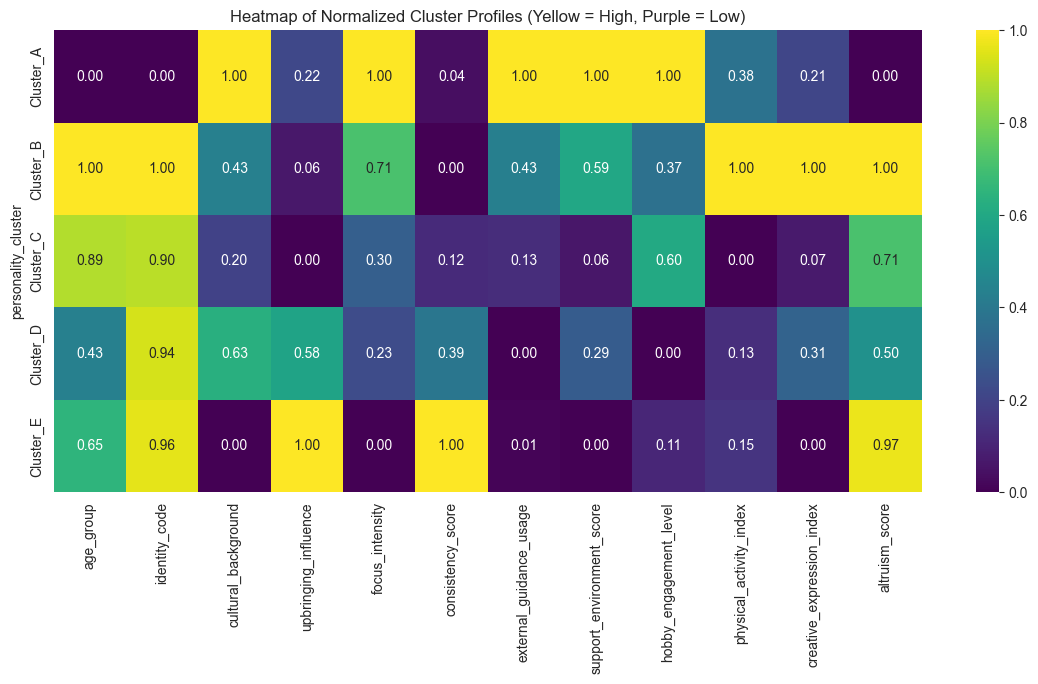

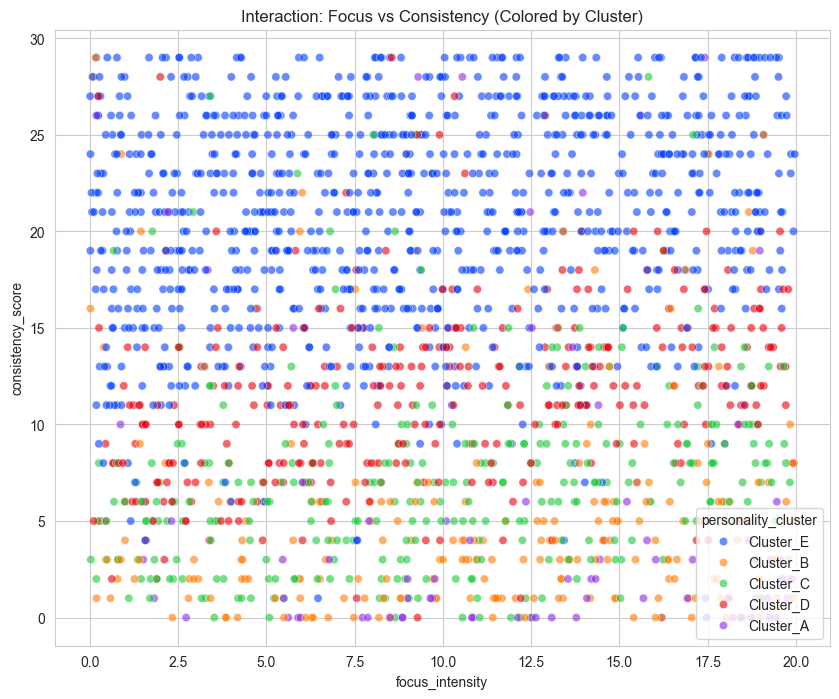

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('train.csv')
print("--- DEEP DIVE ANALYSIS ---")

# ==========================================
# 1. CORRELATION MATRIX (Who is related to whom?)
# ==========================================
# We drop 'participant_id' and 'personality_cluster' (target) for this view
numeric_df = df.select_dtypes(include=['number']).drop('participant_id', axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

# ==========================================
# 2. CLUSTER PROFILING (The "Fingerprint")
# ==========================================
# We group by the target and take the mean of every feature
# This tells us exactly what the "Average Cluster A person" looks like
cluster_profile = df.groupby('personality_cluster').mean(numeric_only=True).drop('participant_id', axis=1)

print("\n[Cluster Fingerprints - Average Values]")
print(cluster_profile)

# Let's visualize the profile of the 'Rare' Cluster A vs the 'Common' Cluster E
# We normalize the data just for the plot so different scales (0-1 vs 0-20) show up together
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
profile_scaled = pd.DataFrame(scaler.fit_transform(cluster_profile), 
                              columns=cluster_profile.columns, 
                              index=cluster_profile.index)

plt.figure(figsize=(14, 6))
sns.heatmap(profile_scaled, cmap="viridis", annot=True, fmt=".2f")
plt.title("Heatmap of Normalized Cluster Profiles (Yellow = High, Purple = Low)")
plt.show()

# ==========================================
# 3. 2D INTERACTION PLOT
# ==========================================
# Can Focus + Consistency separate the classes together?
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='focus_intensity', y='consistency_score', 
                hue='personality_cluster', palette='bright', alpha=0.6)
plt.title("Interaction: Focus vs Consistency (Colored by Cluster)")
plt.show()

--- FINAL EDA STEP: FEATURE IMPORTANCE ---

[Top 5 Most Important Features]
                     Feature  Importance
5          consistency_score    0.447875
4            focus_intensity    0.168869
7  support_environment_score    0.064642
3       upbringing_influence    0.059954
0                  age_group    0.057499


C:\Users\Aksha\AppData\Local\Temp\ipykernel_20392\1274238615.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='magma')


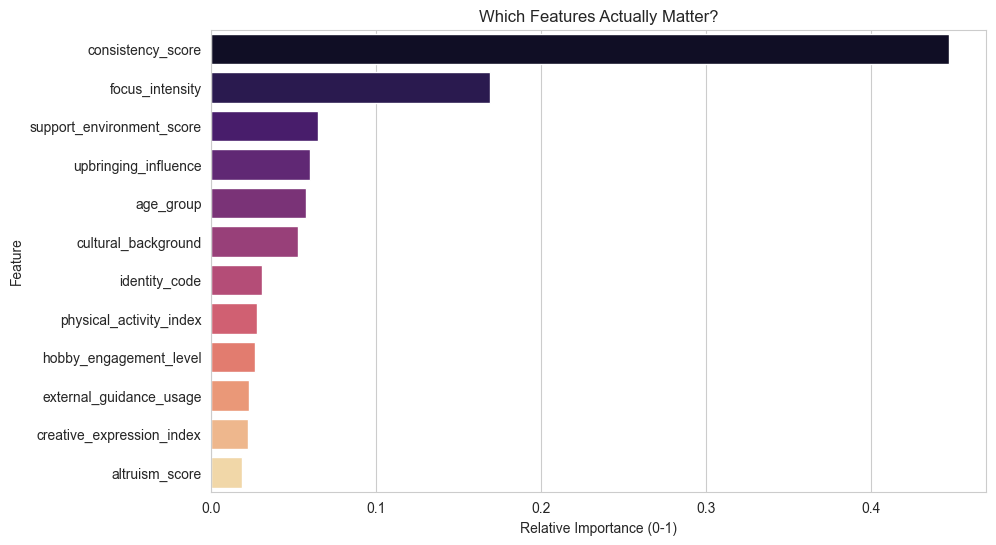

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
df = pd.read_csv('train.csv')

print("--- FINAL EDA STEP: FEATURE IMPORTANCE ---")

# 2. Quick Encoding just for this test
# (We don't care about perfect preprocessing here, just rough numbers)
X = df.drop(['participant_id', 'personality_cluster'], axis=1)
y = df['personality_cluster']

# Convert categorical columns to simple codes for the Random Forest
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# 3. Run a "Quick & Dirty" Model
# We use Random Forest because it handles raw/messy data well
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 4. Extract Feature Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n[Top 5 Most Important Features]")
print(importances.head(5))

# 5. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='magma')
plt.title("Which Features Actually Matter?")
plt.xlabel("Relative Importance (0-1)")
plt.show()

--- FINAL CHECK: THE MINORITY REPORT (A vs B vs C) ---
Analyzing 611 participants in the 'Low Consistency' group.


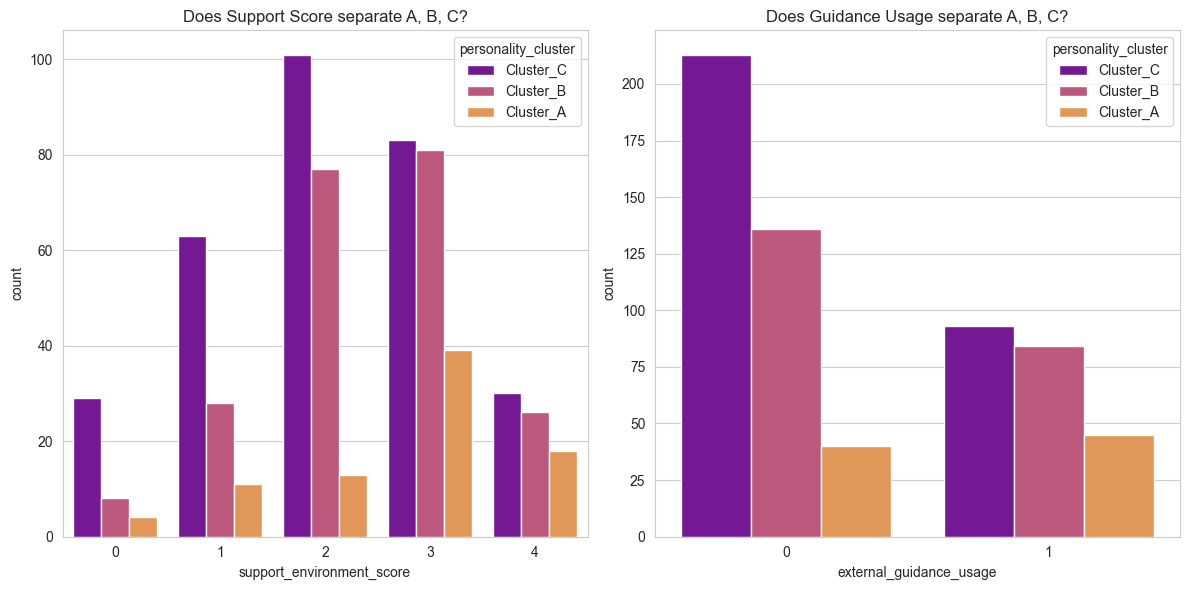


What to look for:
1. Look at Support Score '4' (High): Is it mostly Cluster A?
2. Look at Support Score '0' or '1' (Low): Is it mostly Cluster C?
If yes, the model can separate them. If they are mixed, we have a problem.


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('train.csv')

print("--- FINAL CHECK: THE MINORITY REPORT (A vs B vs C) ---")

# 2. Filter OUT the easy classes (D and E have high consistency, so they are easy)
# We only want to look at the "Low Consistency" group
minority_df = df[df['personality_cluster'].isin(['Cluster_A', 'Cluster_B', 'Cluster_C'])]

print(f"Analyzing {len(minority_df)} participants in the 'Low Consistency' group.")

# 3. The Hypothesis Check
# Hypothesis: Cluster A has High Support, Cluster C has Low Support.
plt.figure(figsize=(12, 6))

# Plot 1: Support Environment Count
plt.subplot(1, 2, 1)
sns.countplot(data=minority_df, x='support_environment_score', hue='personality_cluster', palette='plasma')
plt.title("Does Support Score separate A, B, C?")

# Plot 2: External Guidance Count
plt.subplot(1, 2, 2)
sns.countplot(data=minority_df, x='external_guidance_usage', hue='personality_cluster', palette='plasma')
plt.title("Does Guidance Usage separate A, B, C?")

plt.tight_layout()
plt.show()

print("\nWhat to look for:")
print("1. Look at Support Score '4' (High): Is it mostly Cluster A?")
print("2. Look at Support Score '0' or '1' (Low): Is it mostly Cluster C?")
print("If yes, the model can separate them. If they are mixed, we have a problem.")

--- FINAL SAFETY CHECK: OUTLIERS ---


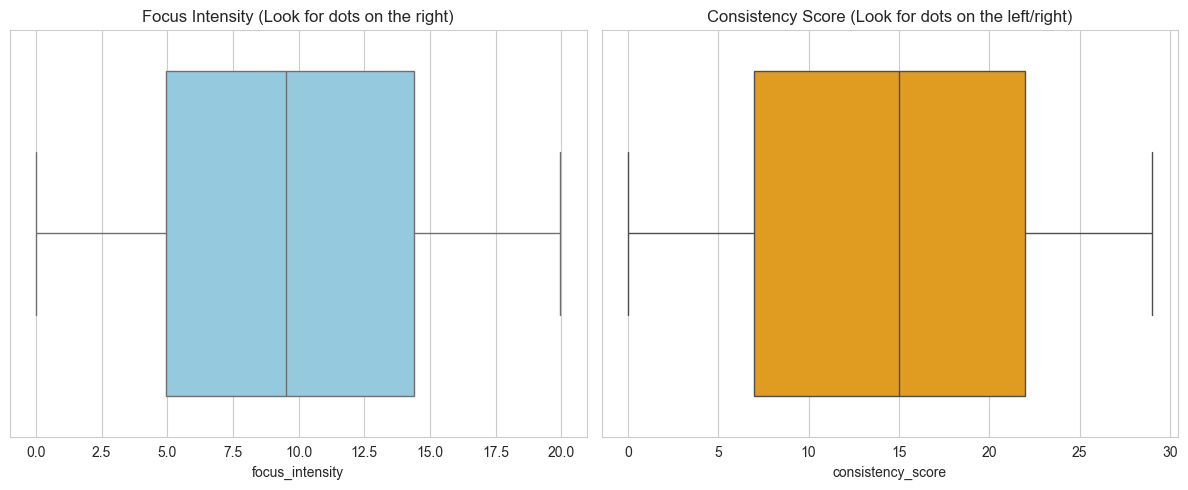


[Logical Range Check]
Focus Range: 0.008030881 to 19.96842468
Consistency Range: 0 to 29


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')

print("--- FINAL SAFETY CHECK: OUTLIERS ---")

plt.figure(figsize=(12, 5))

# Plot 1: Focus Intensity
plt.subplot(1, 2, 1)
sns.boxplot(x=df['focus_intensity'], color='skyblue')
plt.title("Focus Intensity (Look for dots on the right)")

# Plot 2: Consistency Score
plt.subplot(1, 2, 2)
sns.boxplot(x=df['consistency_score'], color='orange')
plt.title("Consistency Score (Look for dots on the left/right)")

plt.tight_layout()
plt.show()

# Logical Sanity Check
print("\n[Logical Range Check]")
print(f"Focus Range: {df['focus_intensity'].min()} to {df['focus_intensity'].max()}")
print(f"Consistency Range: {df['consistency_score'].min()} to {df['consistency_score'].max()}")